# 3. Label efficiency of the self-supervised classifier (DMR-IR)

A ResNet-50 is pretrained with **VICReg** on unlabeled thermal images; its weights are then frozen and only a small MLP head is trained to classify DMR-IR thermograms as healthy or cancer. To measure how many labels this requires, the head was trained with 64 to 512 labeled images (5 folds each) and every model was evaluated on the same held-out test set.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("../results")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#8a8a85",
        "axes.labelcolor": "#2b2b29",
        "axes.titleweight": "semibold",
        "xtick.color": "#5c5c58",
        "ytick.color": "#5c5c58",
        "axes.grid": True,
        "axes.grid.axis": "y",
        "axes.axisbelow": True,
        "grid.color": "#e4e4e0",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
    }
)
BLUE, ORANGE = "#2a78d6", "#eb6834"

In [2]:
df = pd.read_csv(RESULTS / "classification_data_efficiency.csv")
summary = df.groupby("n_samples")[["f1", "precision", "recall", "auc"]].agg(["mean", "std"])
summary.round(3)

f1        precision        recall           auc       
            mean    std      mean    std   mean    std   mean    std
n_samples                                                           
64         0.796  0.081     0.849  0.201  0.792  0.099  0.777  0.162
128        0.925  0.012     0.982  0.017  0.875  0.019  0.929  0.011
192        0.947  0.003     0.994  0.009  0.904  0.014  0.949  0.003
256        0.978  0.010     1.000  0.000  0.957  0.020  0.979  0.010
352        0.986  0.005     1.000  0.000  0.972  0.010  0.986  0.005
416        0.988  0.004     1.000  0.000  0.976  0.008  0.988  0.004
512        0.998  0.002     1.000  0.000  0.996  0.004  0.998  0.002

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


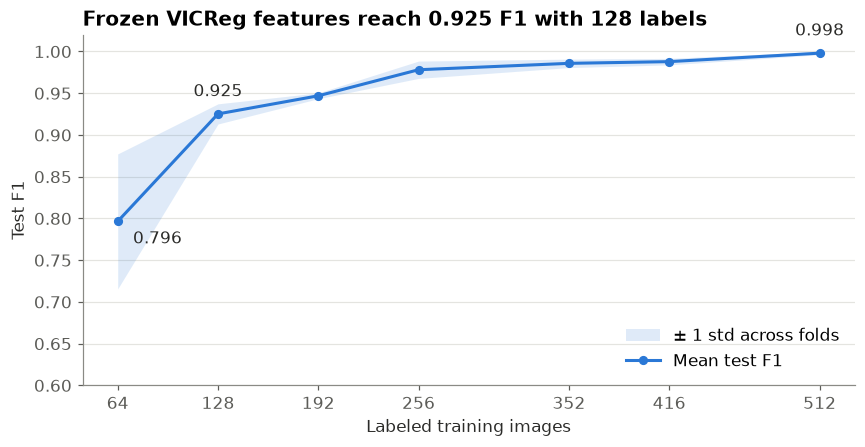

In [3]:
stats = df.groupby("n_samples")["f1"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.fill_between(stats.index, stats["mean"] - stats["std"], stats["mean"] + stats["std"],
                color=BLUE, alpha=0.15, linewidth=0, label="± 1 std across folds")
ax.plot(stats.index, stats["mean"], color=BLUE, linewidth=2, marker="o", markersize=5,
        label="Mean test F1")
label_offsets = {
    64: (10, -6, "left", "top"),
    128: (0, 9, "center", "bottom"),
    512: (0, 9, "center", "bottom"),
}
for n, (dx, dy, ha, va) in label_offsets.items():
    ax.annotate(
        f"{stats.loc[n, 'mean']:.3f}",
        (n, stats.loc[n, "mean"]),
        textcoords="offset points",
        xytext=(dx, dy),
        ha=ha,
        va=va,
        color="#2b2b29",
    )
ax.set_xticks(stats.index)
ax.set_xlabel("Labeled training images")
ax.set_ylabel("Test F1")
ax.set_ylim(0.6, 1.02)
ax.set_title("Frozen VICReg features reach 0.925 F1 with 128 labels", loc="left")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "classification_data_efficiency.png", dpi=200)

**Takeaways**

- With only 64 labels the classifier is unstable (one fold collapses to AUC 0.49).
- From 128 labels on, results are consistent across folds: F1 0.925 ± 0.012.
- Performance keeps improving with more labels: 0.978 F1 at 256, 0.986 at 352 and 0.998 at 512.